In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "base")))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, random
from functools import partial

jax.config.update("jax_enable_x64", True)

from tools import (
    I, X, Z,
    bracket, antibracket,
    channel_pack,
    run_trajectories_ito,
    run_trajectories_ito_nomonitor
)

In [2]:
@partial(jit, static_argnames=("n_steps",))
def run(rho0, key, n_steps, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt):
    return run_trajectories_ito_nomonitor(
        rho0, key, n_steps,
        pack_error, pack_ec,
        gamma_error, gamma_ec,
        Omega1, Omega2, dt,
    )

# SB-DB feedback with Luispe's operators (Itô)

In [3]:
# =============================================================================
# FEEDBACK-SPECIFIC: choose dΩ via Omega1 / Omega2 (SBDB example)
# =============================================================================

def build_omega_luispe(PQ, R, A, gammaEC):
    """
    Compute Omega1 and Omega2 in Luispe's feedback scheme.

    Omega2 = i [PQ, R]/2
    Omega1 = -gammaEC/2 * antibracket(A, Omega2)

    Parameters
    ----------
    PQ : array_like (N, N)             # Projector
    R  : array_like (n_ec, N, N)       # e.g., X1, X2, X3
    A  : array_like (n_ec, N, N)       # C4, C5, C6
    gammaEC : array_like (n_ec,)       # feedback rates

    Returns
    -------
    Omega1, Omega2 : each (n_ec, N, N)
    """
    n_ec = R.shape[0]
    PQ_rep = jnp.broadcast_to(PQ, (n_ec, PQ.shape[-2], PQ.shape[-1]))
    # [PQ, R]
    Omega2 = 1j * bracket(PQ_rep, R) / 2.0

    # Fix: gammaEC has shape (n_ec,), antibracket(A, Omega2) has (n_ec, N, N)
    # Need to reshape gammaEC so it broadcasts correctly
    Omega1 = -gammaEC[:, None, None] / 2.0 * antibracket(A, Omega2)

    return Omega1, Omega2


In [4]:
# =============================================================================
# OPERATORS / SETUP
# =============================================================================

n = 3
N = 2**n

T = 10.0
L = 1000
dt = T / L
n_traj = 50

gamma_error = 1e-3 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = 1 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)

e000 = jnp.zeros((N), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

C_error = jnp.stack([X1, X2, X3], axis=0)

lamb = 1.

C4 = 0.5 * antibracket(PQ, X1) + lamb * X1 @ PQ @ X1
C5 = 0.5 * antibracket(PQ, X2) + lamb * X2 @ PQ @ X2
C6 = 0.5 * antibracket(PQ, X3) + lamb * X3 @ PQ @ X3
C_ec = jnp.stack([C4, C5, C6], axis=0)

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)

# Omega1, Omega2 = build_omega_sbdb(
#     pack_ec["A"], pack_ec["B"], PQ, gamma_ec
# )

Omega1, Omega2 = build_omega_luispe(PQ, C_error, C_ec, gamma_ec)

# Omega1 = jnp.zeros_like(pack_ec["A"])
# Omega2 = jnp.zeros_like(pack_ec["A"])

q = e000
Q = q[:, None] @ jnp.conj(q)[None, :]

var = 0e-2  # example variance, adjust as needed
noise = jax.random.normal(random.PRNGKey(42), q.shape, dtype=q.dtype) * jnp.sqrt(var)
psi0 = q + noise
psi0 = psi0 / jnp.linalg.norm(psi0)
P0 = psi0[:, None] * jnp.conj(psi0)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))


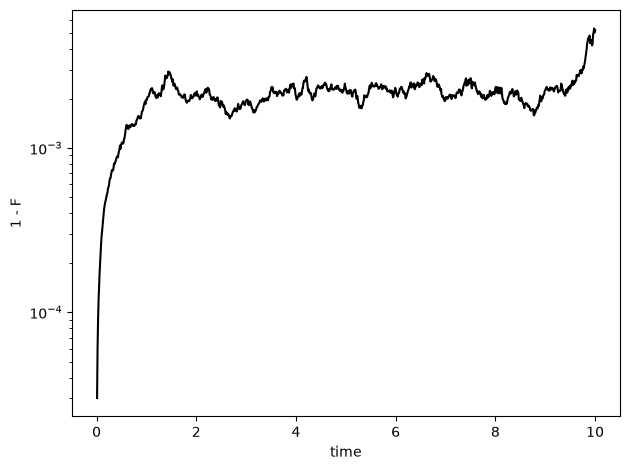

In [5]:
key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()

F_all = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))

times = dt * jnp.arange(1, L + 1)
mean_F = jnp.mean(F_all, axis=1)

plt.figure(2)
plt.semilogy(times, 1.0 - jnp.abs(mean_F), "k")
plt.xlabel("time")
plt.ylabel("1 - F")
plt.tight_layout()
plt.show()


In [ ]:
float(jnp.max(jnp.abs(1 - mean_F)))

0.0

In [6]:
def J_corr(Rop, gammaC, lam):
    return gammaC * (P_C @ Rop + lam * Rop @ P_C @ Rop)

|██████████| 100.0% ◆ elapsed 3.18ms ◆ remaining 0.00ms


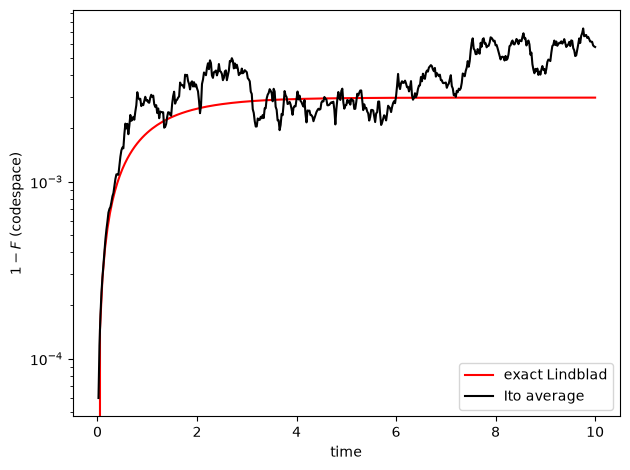

In [7]:
# Exact Lindblad vs Ito stochastic average — same params, expanded jumps {I, X1, X2, X3}
import dynamiqs as dq

n = 3
N = 2**n
T = 10.0
L = 500
dt = T / L
n_traj = 1000
lamb = 1.0
gamma_E = 1e-3
gamma_C = 1.0

gamma_error = gamma_E * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = gamma_C * jnp.array([1.0, 1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Id3 = jnp.eye(N, dtype=jnp.complex128)

e000 = jnp.zeros((N,), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N,), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

R = jnp.stack([Id3, X1, X2, X3], axis=0)
PQ_rep = jnp.broadcast_to(PQ, (R.shape[0], N, N))
C_error = jnp.stack([X1, X2, X3], axis=0)
C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)
Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)

P0 = e000[:, None] * jnp.conj(e000)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))

key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()
F_stoch = jnp.mean(jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ)), axis=1)
times = dt * jnp.arange(1, L + 1)

# Unconditional Lindblad: L^E = √γ_E X_i and J_s = √γ_C (P_C R + λ R P_C R)
X1_dq = dq.tensor(dq.sigmax(), dq.eye(2), dq.eye(2))
X2_dq = dq.tensor(dq.eye(2), dq.sigmax(), dq.eye(2))
X3_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.sigmax())
Id_dq = dq.tensor(dq.eye(2), dq.eye(2), dq.eye(2))
ket000 = dq.tensor(dq.basis(2, 0), dq.basis(2, 0), dq.basis(2, 0))
ket111 = dq.tensor(dq.basis(2, 1), dq.basis(2, 1), dq.basis(2, 1))
P_C = ket000.proj() + ket111.proj()


jump_ops = [
    jnp.sqrt(gamma_E) * X1_dq,
    jnp.sqrt(gamma_E) * X2_dq,
    jnp.sqrt(gamma_E) * X3_dq,
    J_corr(Id_dq, gamma_C, lamb),
    J_corr(X1_dq, gamma_C, lamb),
    J_corr(X2_dq, gamma_C, lamb),
    J_corr(X3_dq, gamma_C, lamb),
]
tsave = jnp.linspace(0.0, T, 201)
result = dq.mesolve(0 * Id_dq, jump_ops, ket000, tsave, exp_ops=[P_C])
F_exact = jnp.real(result.expects[0])

plt.figure()
plt.semilogy(tsave, 1.0 - jnp.abs(F_exact), "r", label="exact Lindblad")
plt.semilogy(times, 1.0 - jnp.abs(F_stoch), "k", label="Ito average")
plt.xlabel("time")
plt.ylabel(r"$1-F$ (codespace)")
plt.legend()
plt.tight_layout()
plt.show()


⟨A⟩(t=0) = [0.0, 1.0, 0.0, 0.0]


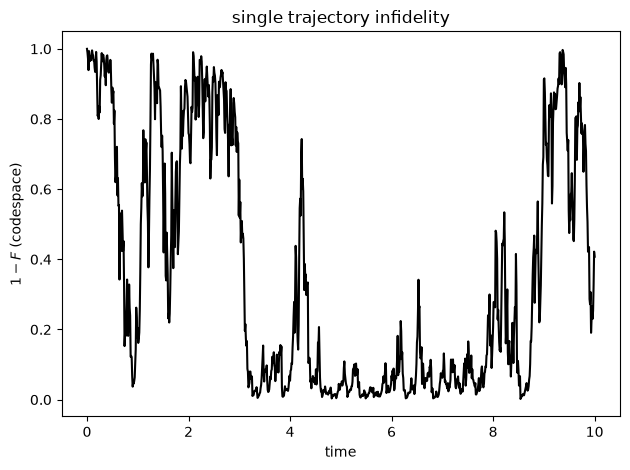

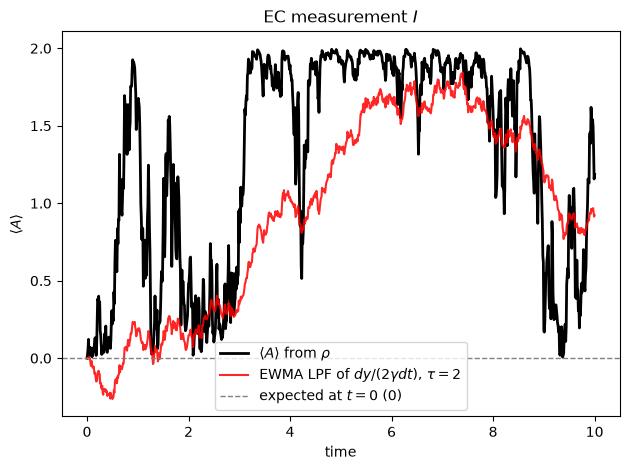

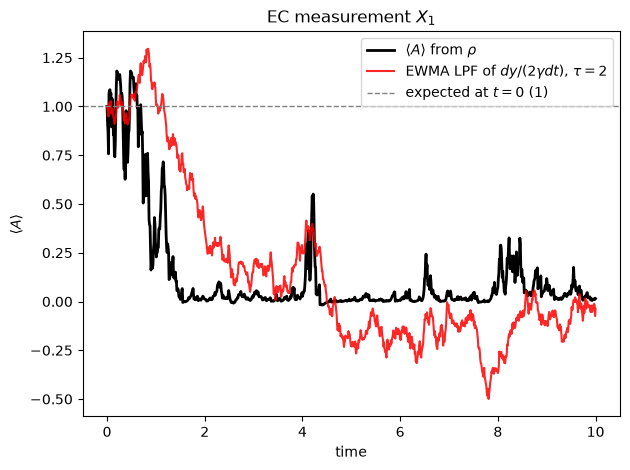

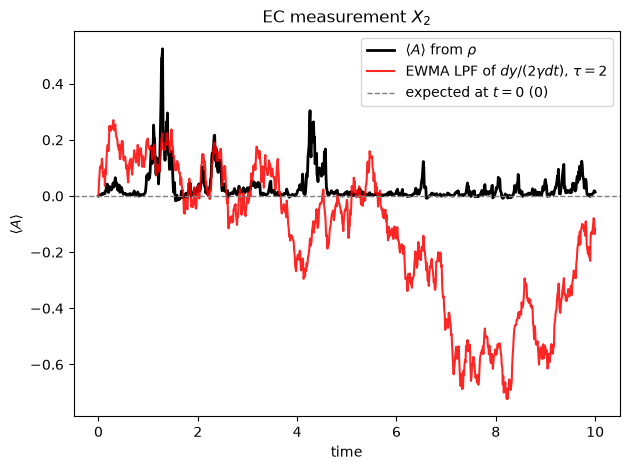

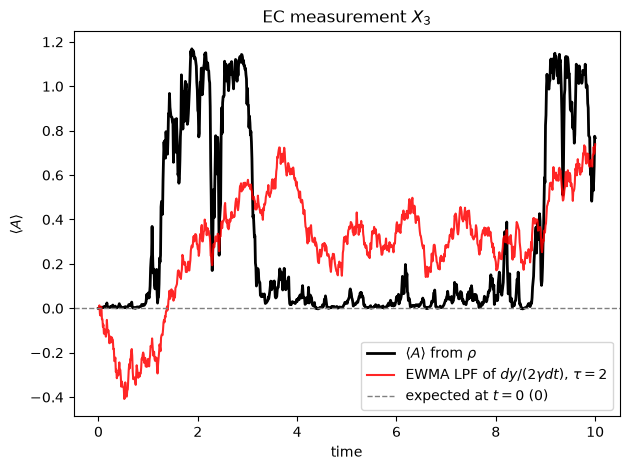

In [25]:
# Single Ito trajectory: infidelity + ⟨A⟩ (X1 should start at λ on |100⟩)
from jax import lax
from tools import measurement_increments, one_step_ito_nomonitor

# Basis states for all 3-qubit computational states |ijk⟩, where i,j,k ∈ {0,1}
def basis_state(index, N):
    """Return N-dimensional standard basis vector with 1 at index."""
    return jnp.zeros((N,), dtype=jnp.complex128).at[index].set(1.0)

n = 3
N = 2**n
T = 10.0
L = 1000
dt = T / L
n_traj = 1
traj = 0
gamma_E = 1e-1
lamb = 1
gamma_C = 1

# Only EC channel parameters needed now
gamma_error = gamma_E * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)  # error channel rates (unused downstream)
gamma_ec = gamma_C * jnp.array([1.0, 1.0, 1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)
Id3 = jnp.eye(N, dtype=jnp.complex128)

e000 = basis_state(0b000, N)
e001 = basis_state(0b001, N)
e010 = basis_state(0b010, N)
e011 = basis_state(0b011, N)
e100 = basis_state(0b100, N)
e101 = basis_state(0b101, N)
e110 = basis_state(0b110, N)
e111 = basis_state(0b111, N)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

R = jnp.stack([Id3, X1, X2, X3], axis=0)
PQ_rep = jnp.broadcast_to(PQ, (R.shape[0], N, N))
C_error = jnp.stack([X1, X2, X3], axis=0)  # unused by the simulation

C_ec = 0.5 * antibracket(PQ_rep, R) + lamb * jnp.matmul(R, jnp.matmul(PQ_rep, R))

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)
Omega1, Omega2 = build_omega_luispe(PQ, R, C_ec, gamma_ec)

P0 = e000[:, None] * jnp.conj(e000)[None, :]
#rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))
rho0 = jnp.broadcast_to(e100[:, None] * jnp.conj(e100)[None, :][None, :, :], (n_traj, N, N))


@partial(jit, static_argnames=("n_steps",))
def run_ito_with_dy_nomonitor(rho0, key, n_steps, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt):
    n_traj = rho0.shape[0]
    # The EC measurement noise increments have variance dt (not gamma*dt),
    # since the gamma factors are absorbed into the dissipator/jump terms.
    dw_ec = jnp.sqrt(gamma_C * dt) * random.normal(
        key, (n_steps, n_traj, gamma_ec.shape[0])
    )

    def body(rho, dw_c):
        # This will internally use gamma_ec for scaling, and expects dw_c ~ N(0, dt)
        dy_c = measurement_increments(rho, pack_ec["A"], gamma_ec, dw_c, dt)
        rho = one_step_ito_nomonitor(
            rho, dw_c, pack_error, pack_ec,
            gamma_error, gamma_ec, Omega1, Omega2, dt,
        )
        return rho, (rho, dy_c)

    _, (rho_all, dy_c_all) = lax.scan(body, rho0, dw_ec)
    return rho_all, dy_c_all

rho_all, dy_ec = run_ito_with_dy_nomonitor(
    rho0, random.PRNGKey(0), L, pack_error, pack_ec,
    gamma_error, gamma_ec, Omega1, Omega2, dt,
)
rho_all.block_until_ready()


# --- t=0 prepended so ⟨A⟩ starts at the initial-state value ---
times = dt * jnp.arange(1, L + 1)
times_plot = jnp.concatenate([jnp.array([0.0]), times])

F0 = jnp.real(jnp.einsum("ij,ji", rho0[traj], PQ))
F_traj = jnp.real(jnp.einsum("sij,ji->s", rho_all[:, traj], PQ))
F_traj_plot = jnp.concatenate([jnp.array([F0]), F_traj])

# Noiseless homodyne observable: ⟨A_i⟩ = Tr(A_i ρ). On |100⟩, ⟨A_{X1}⟩ = λ.
A_ops = pack_ec["A"]
A0 = jnp.real(jnp.einsum("cij,ji->c", A_ops, rho0[traj]))
A_traj = jnp.real(jnp.einsum("cij,sji->sc", A_ops, rho_all[:, traj]))
A_plot = jnp.concatenate([A0[None, :], A_traj], axis=0)

# dy = 2 γ ⟨A⟩ dt + dw  →  noisy per-step estimate of ⟨A⟩ is dy / (2 γ dt)
A_from_dy = dy_ec[:, traj] / (2.0 * gamma_ec[None, :] * dt)

# Causal first-order LPF  τ ṁ = x − m  ⇔  EWMA  m ← (1−α)m + α x
# Knob: larger tau_smooth → more smoothing (lower cutoff). tau_smooth → 0 is raw dy/(2γ dt).
tau_smooth = 2
alpha = 1.0 - jnp.exp(-dt / tau_smooth)

def ewma_lpf(m, x):
    m = (1.0 - alpha) * m + alpha * x
    return m, m

_, A_filt = lax.scan(ewma_lpf, A0, A_from_dy)
A_filt_plot = jnp.concatenate([A0[None, :], A_filt], axis=0)

print("⟨A⟩(t=0) =", [float(x) for x in A0])

plt.figure()
plt.plot(times_plot, 1.0 - jnp.abs(F_traj_plot), "k")
plt.xlabel("time")
plt.ylabel(r"$1-F$ (codespace)")
plt.title("single trajectory infidelity")
plt.tight_layout()
plt.show()

ec_labels = [r"$I$", r"$X_1$", r"$X_2$", r"$X_3$"]
A0_expect = [0.0, lamb, 0.0, 0.0]  # ⟨A⟩ on |100⟩

for i, lab in enumerate(ec_labels):
    plt.figure()
    plt.plot(times_plot, A_plot[:, i], "k", lw=2, label=r"$\langle A\rangle$ from $\rho$")
    plt.plot(times_plot, A_filt_plot[:, i], "r", alpha=0.85,
             label=rf"EWMA LPF of $dy/(2\gamma dt)$, $\tau={tau_smooth:g}$")
    plt.axhline(A0_expect[i], color="gray", ls="--", lw=1, label=rf"expected at $t=0$ ({A0_expect[i]:g})")
    plt.xlabel("time")
    plt.ylabel(r"$\langle A\rangle$")
    plt.title(rf"EC measurement {lab}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# $TS$-rotation feedback

In [4]:
del run

In [4]:
# =============================================================================
# FEEDBACK-SPECIFIC: choose dΩ via Omega1 / Omega2 (SBDB example)
# =============================================================================


# def build_omega_STrotation(A, B, gamma):
#     """
#     ST-rotation feedback: set Omegas from
#         dΩ_t = (π/2) dH^S_SB
#     where
#         dH^S_SB = -i (γ/2) {A, B} dt + i B dY_t

#     A, B: (n_ec, N, N), PQ: (N, N), gamma: (n_ec,)
#     Returns Omega1, Omega2 each (n_ec, N, N).
#     """
#     g = jnp.asarray(gamma, dtype=A.real.dtype)[:, None, None]
#     anticomAB = antibracket(A, B)

#     gamma_fb = 1

#     # Omega1 multiplies dt, Omega2 multiplies dY_t
#     Omega1 = gamma_fb * (-1j * (g / 2.0) * anticomAB)
#     Omega2 = gamma_fb * (1j * B)
#     return Omega1, Omega2

def build_omega_STrotation():
    # Omega1 is set to 0 (no dt feedback here)
    Omega1 = jnp.zeros((2, N, N), dtype=complex)
    # Omega2 is a stack of two operators, each (N,N):
    # First: i * Z1Z2 * (X1/2), Second: i * Z2Z3 * (X2/2)
    O2_1 = 1j * Z1Z2 @ (X1 / 2)
    O2_2 = 1j * Z2Z3 @ (X3 / 2)
    gamma_fb = 1
    Omega2 = gamma_fb * jnp.stack([O2_1, O2_2], axis=0)
    return Omega1, Omega2

# =============================================================================
# OPERATORS / SETUP
# =============================================================================

n = 3
N = 2**n

T = 10.0
L = 1000
dt = T / L
n_traj = 50

gamma_error = 1e-3 * jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
gamma_ec = 1 * jnp.array([1.0, 1.0], dtype=jnp.float64)

X1 = jnp.kron(jnp.kron(X, I), I)
X2 = jnp.kron(jnp.kron(I, X), I)
X3 = jnp.kron(jnp.kron(I, I), X)

Id = jnp.eye(8, dtype=jnp.float64)

Z1Z2 = jnp.kron(jnp.kron(Z, Z), I)
Z2Z3 = jnp.kron(jnp.kron(I, Z), Z)

e000 = jnp.zeros((N), dtype=jnp.complex128).at[0].set(1.0)
e111 = jnp.zeros((N), dtype=jnp.complex128).at[-1].set(1.0)
PQ = e000[:, None] * jnp.conj(e000)[None, :] + e111[:, None] * jnp.conj(e111)[None, :]

C_error = jnp.stack([X1, X2, X3], axis=0)

C4 = X1/2
C5 = X3/2
C_ec = jnp.stack([C4, C5], axis=0)

pack_error = channel_pack(C_error)
pack_ec = channel_pack(C_ec)

Omega1, Omega2 = build_omega_STrotation()
# Omega1 = jnp.zeros((2, N, N), dtype=complex)
# Omega2 = jnp.zeros((2, N, N), dtype=complex)


q = e000
Q = q[:, None] @ jnp.conj(q)[None, :]

var = 0e-2  # example variance, adjust as needed
noise = jax.random.normal(random.PRNGKey(42), q.shape, dtype=q.dtype) * jnp.sqrt(var)
psi0 = q + noise
psi0 = psi0 / jnp.linalg.norm(psi0)
P0 = psi0[:, None] * jnp.conj(psi0)[None, :]
rho0 = jnp.broadcast_to(P0[None, :, :], (n_traj, N, N))

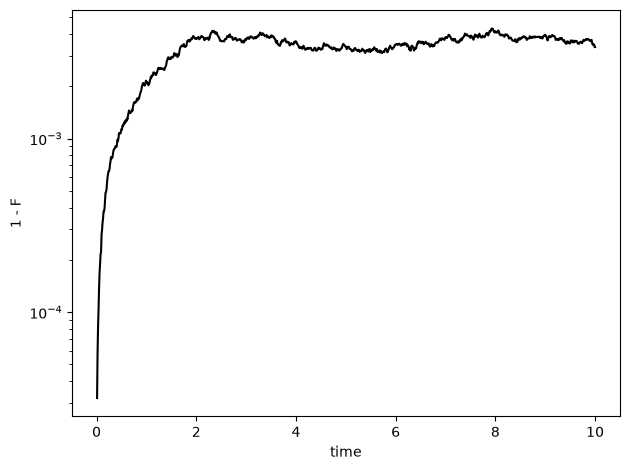

In [5]:
key = random.PRNGKey(0)
rho_all = run(rho0, key, L, pack_error, pack_ec, gamma_error, gamma_ec, Omega1, Omega2, dt)
rho_all.block_until_ready()

F_all = jnp.real(jnp.einsum("stij,ji->st", rho_all, PQ))

times = dt * jnp.arange(1, L + 1)
mean_F = jnp.mean(F_all, axis=1)

plt.figure(2)
plt.semilogy(times, 1.0 - jnp.abs(mean_F), "k")
plt.xlabel("time")
plt.ylabel("1 - F")
plt.tight_layout()
plt.show()


In [14]:
float(jnp.max(jnp.abs(mean_F)))

0.9999679778986266